#### Human-in-the-Loop (HITL) Branching Workflow: Secure Financial Transaction of Fraud Prevention & Multi-Factor Compliance in High-Value Transactions
- A LangGraph banking agent that auto-handles safe queries (balance checks) but pauses for human approval before executing sensitive actions (money transfers).

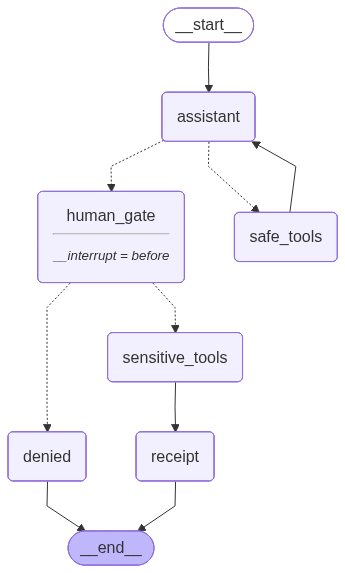


User: What is the bank balance of account ACC001?

[assistant] Thinking...

[assistant_router] 'check_balance' is safe → safe_tools

[assistant] Thinking...

[assistant_router] No tool call → END

Completed automatically — no approval required.
   → The balance for account ACC001 is $5000.


User: Transfer $100 to Bob

[assistant] Thinking...

[assistant_router] 'transfer_money' is sensitive → human_gate

Graph paused — assistant wants to run:
   Tool      : transfer_money
   Arguments : {'recipient': 'Bob', 'amount': 100.0}
   Next node : ('human_gate',)

--- Rejected ---

[assistant_router] 'transfer_money' is sensitive → human_gate


[human_gate] Resuming after human decision...

[approval_router] Rejected → denied

[denied] Transfer cancelled.
   → Transfer cancelled. No money was moved.

Final message : Transfer cancelled. No money was moved.
Graph ended   : True


In [3]:
import os
from typing import Annotated, Literal
from typing_extensions import TypedDict
from dotenv import load_dotenv
from langchain_google_vertexai import ChatVertexAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

load_dotenv()

# ─────────────────────────────────────────────
# 1. TOOLS
# ─────────────────────────────────────────────

def transfer_money(amount: int, recipient: str) -> str:
    """Transfer money to a recipient."""
    return f"Successfully transferred ${amount} to {recipient}."

def check_balance(account_id: str) -> str:
    """Check the current balance for a given account ID."""
    balances = {"ACC001": 5000, "ACC002": 1200, "ACC003": 300}
    balance = balances.get(account_id.upper(), None)
    if balance is None:
        return f"Account {account_id} not found."
    return f"Account {account_id} has a balance of ${balance}."

# LLM sees ALL tools — this is what gets bound to the model
all_tools = [check_balance, transfer_money]

# Split purely for execution routing — does NOT affect what LLM sees
safe_tools      = [check_balance]    # runs immediately, no approval
sensitive_tools = [transfer_money]   # pauses for human approval

SENSITIVE_TOOL_NAMES = {t.__name__ for t in sensitive_tools}  # {"transfer_money"}

# ─────────────────────────────────────────────
# 2. LLM  — binds ALL tools so it can call any of them
# ─────────────────────────────────────────────

llm = ChatVertexAI(
    model="gemini-2.5-pro",
    project=os.getenv("GCP_PROJECT_ID"),
    location="us-central1",
    temperature=0,
)
llm_with_tools = llm.bind_tools(all_tools)   # ← ALL tools here

# ─────────────────────────────────────────────
# 3. STATE
# ─────────────────────────────────────────────

class AgentState(TypedDict):
    messages:       Annotated[list[BaseMessage], add_messages]
    human_approved: bool   # set by human via update_state(), read by approval_router

# ─────────────────────────────────────────────
# 4. NODES
# ─────────────────────────────────────────────

def call_assistant(state: AgentState):
    """
    LLM runs here every time.
    - First call:  decides which tool to call
    - Second call: summarizes the tool result (for safe tools like check_balance)
    """
    print("\n[assistant] Thinking...")
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

def human_gate(state: AgentState):
    """
    Interrupt anchor node — does nothing itself.
    graph pauses BEFORE this node runs (interrupt_before=["human_gate"]).
    When human resumes, approval_router reads human_approved and picks the next path.
    """
    print("\n[human_gate] Resuming after human decision...")
    return {}

def receipt_node(state: AgentState):
    """Reached only after a successful transfer (human approved)."""
    print("\n[receipt] Transfer complete.")
    return {"messages": [AIMessage(content="Transfer confirmed. Receipt sent to your email.")]}

def denied_node(state: AgentState):
    """Reached only when human rejected the transfer."""
    print("\n[denied] Transfer cancelled.")
    return {"messages": [AIMessage(content="Transfer cancelled. No money was moved.")]}

# ─────────────────────────────────────────────
# 5. ROUTERS
# ─────────────────────────────────────────────

def assistant_router(state: AgentState) -> Literal["human_gate", "safe_tools", "__end__"]:
    """
    Runs after every assistant call. Three possible outcomes:

    Case 1 — LLM called a SENSITIVE tool (transfer_money):
              → human_gate   pause, wait for human approval

    Case 2 — LLM called a SAFE tool (check_balance):
              → safe_tools   run immediately, no approval needed

    Case 3 — LLM produced a plain text reply (no tool call):
              → END          conversation is complete
                             (this fires on the SECOND assistant call
                              after safe_tools returns its result
                              and LLM summarizes it in plain text)
    """
    last_msg = state["messages"][-1]

    if not last_msg.tool_calls:
        # No tool call — LLM either answered directly or summarized a tool result
        print("\n[assistant_router] No tool call → END")
        return "__end__"

    tool_name = last_msg.tool_calls[0]["name"]

    if tool_name in SENSITIVE_TOOL_NAMES:
        print(f"\n[assistant_router] '{tool_name}' is sensitive → human_gate")
        return "human_gate"

    print(f"\n[assistant_router] '{tool_name}' is safe → safe_tools")
    return "safe_tools"


def approval_router(state: AgentState) -> Literal["sensitive_tools", "denied"]:
    """
    Runs after human_gate resumes.
    Reads the human_approved flag that the human set via graph.update_state().
    """
    if state.get("human_approved", False):
        print("\n[approval_router] Approved → sensitive_tools")
        return "sensitive_tools"
    print("\n[approval_router] Rejected → denied")
    return "denied"

# ─────────────────────────────────────────────
# 6. BUILD GRAPH
# ─────────────────────────────────────────────
#
# Full edge map:
#
#   START
#     → assistant
#         → human_gate  (sensitive tool called)
#               → sensitive_tools  (approved)  → receipt → END
#               → denied           (rejected)             → END
#         → safe_tools  (safe tool called)
#               → assistant   ← loops back so LLM can summarize result
#         → END  (no tool call — plain text reply)
#
# ─────────────────────────────────────────────

builder = StateGraph(AgentState)

builder.add_node("assistant",       call_assistant)
builder.add_node("human_gate",      human_gate)
builder.add_node("safe_tools",      ToolNode(safe_tools))        # executes check_balance
builder.add_node("sensitive_tools", ToolNode(sensitive_tools))   # executes transfer_money
builder.add_node("receipt",         receipt_node)
builder.add_node("denied",          denied_node)

# START → assistant (always)
builder.add_edge(START, "assistant")

# assistant → human_gate | safe_tools | END
builder.add_conditional_edges(
    "assistant",
    assistant_router,
    {
        "human_gate":  "human_gate",
        "safe_tools":  "safe_tools",
        "__end__":           END
    }
)

# human_gate → sensitive_tools | denied
builder.add_conditional_edges(
    "human_gate",
    approval_router,
    {
        "sensitive_tools": "sensitive_tools",
        "denied":          "denied"
    }
)

# solid edges — no conditional needed, destination is always the same
builder.add_edge("safe_tools",      "assistant")  # loop back: LLM summarizes result
builder.add_edge("sensitive_tools", "receipt")    # transfer done → show receipt
builder.add_edge("receipt",         END)
builder.add_edge("denied",          END)

# ─────────────────────────────────────────────
# 7. COMPILE
# ─────────────────────────────────────────────

memory = MemorySaver()
graph = builder.compile(
    checkpointer=memory,
    interrupt_before=["human_gate"],   # only fires when sensitive tool is called
)

# Plot the graph — you should see:
#   assistant → human_gate, safe_tools, END   (3 outgoing edges)
#   human_gate → sensitive_tools, denied      (2 outgoing edges)
#   safe_tools → assistant                    (solid loop back)
#   sensitive_tools → receipt → END           (solid straight line)
#   denied → END                              (solid straight line)
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

# ─────────────────────────────────────────────
# 8. EXECUTION
# ─────────────────────────────────────────────

def run_demo(user_message: str, thread_id: str):
    thread = {"configurable": {"thread_id": thread_id}}

    print("\n" + "=" * 55)
    print(f"User: {user_message}")
    print("=" * 55)

    # Step 1: Run graph — stops at interrupt OR finishes completely
    graph.invoke(
        {
            "messages":       [HumanMessage(content=user_message)],
            "human_approved": False,
        },
        config=thread,
    )

    snapshot = graph.get_state(thread)

    # ── Path A: graph already finished (safe tool — no HITL needed) ──
    if snapshot.next == ():
        print("\nCompleted automatically — no approval required.")
        print(f"   → {snapshot.values['messages'][-1].content}")
        return

    # ── Path B: graph paused at human_gate (sensitive tool) ──
    pending   = snapshot.values["messages"][-1]   # AIMessage with tool_calls
    tool_call = pending.tool_calls[0]

    print(f"\nGraph paused — assistant wants to run:")
    print(f"   Tool      : {tool_call['name']}")
    print(f"   Arguments : {tool_call['args']}")
    print(f"   Next node : {snapshot.next}")

    # Step 2: Human decides
    user_choice = input("\nDo you approve? (yes/no): ").strip().lower()

    if user_choice == "yes":
        print("\n--- Approved ---")
        graph.update_state(thread, {"human_approved": True})
    else:
        print("\n--- Rejected ---")
        graph.update_state(thread, {"human_approved": False})

    # Step 3: Resume — human_gate runs, approval_router picks path
    print()
    for event in graph.stream(None, config=thread, stream_mode="values"):
        last = event["messages"][-1]
        if hasattr(last, "content") and last.content:
            print(f"   → {last.content}")

    # Step 4: Final summary
    final = graph.get_state(thread)
    print(f"\nFinal message : {final.values['messages'][-1].content}")
    print(f"Graph ended   : {final.next == ()}")


# ─────────────────────────────────────────────
# 9. RUN BOTH SCENARIOS
# ─────────────────────────────────────────────

# Scenario A — safe tool: check_balance
# Flow: assistant → safe_tools → assistant → END
# No interrupt, no approval prompt
run_demo(
    user_message="What is the bank balance of account ACC001?",
    thread_id="session_balance",
)

# Scenario B — sensitive tool: transfer_money
# Flow: assistant → human_gate ⏸ → sensitive_tools → receipt → END
#                              ↘ denied → END
run_demo(
    user_message="Transfer $100 to Bob",
    thread_id="session_transfer",
)